<a href="https://colab.research.google.com/github/truehack/-/blob/2main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error, accuracy_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.preprocessing import OneHotEncoder
from scipy import stats


%matplotlib inline
sns.set(color_codes=True)

In [4]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [5]:
import pandas as pd
import os

file_path = '/content/drive/MyDrive/Colab Notebooks/student_lifestyle_100k.csv'
df = pd.read_csv(file_path)
df

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False
...,...,...,...,...,...,...,...,...,...,...,...
99995,100996,24,Female,Medical,2.02,7.0,0.6,1.4,66,4,False
99996,100997,24,Male,Arts,2.33,5.0,3.6,5.2,103,3,False
99997,100998,24,Female,Engineering,2.23,6.5,5.8,4.1,61,5,False
99998,100999,19,Male,Engineering,3.61,6.1,4.8,4.9,116,4,False


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  object 
 3   Department          100000 non-null  object 
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), object(2)
memory usage: 7.7+ MB


In [7]:
df.isna().sum() # проверка на пропуски

,0
Student_ID,0
Age,0
Gender,0
Department,0
CGPA,0
Sleep_Duration,0
Study_Hours,0
Social_Media_Hours,0
Physical_Activity,0
Stress_Level,0


In [8]:
df.describe() # работа с поиском выбросов


,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,51000.500000,21.009010,2.898316,6.996425,4.509517,3.503288,74.353180,4.131660
std,28867.657797,2.000382,0.532240,1.498682,1.976076,1.486852,43.366963,1.424151
min,1001.000000,18.000000,1.560000,3.000000,0.000000,0.000000,0.000000,2.000000
25%,26000.750000,19.000000,2.450000,6.000000,3.200000,2.500000,37.000000,3.000000
50%,51000.500000,21.000000,2.900000,7.000000,4.500000,3.500000,74.000000,4.000000
75%,76000.250000,23.000000,3.350000,8.000000,5.800000,4.500000,112.000000,5.000000
max,101000.000000,24.000000,4.000000,12.000000,12.800000,10.000000,149.000000,10.000000


In [9]:
# массив всех числовых признаков
Q = df.select_dtypes(include=['number']).columns.tolist()
Q.remove('Student_ID')

In [10]:

for i in Q:
  Q1 = df[i].quantile(0.25)
  Q3 = df[i].quantile(0.75)
  IQR = Q3 - Q1
  a = Q1 - 1.5*IQR
  b = Q3 + 1.5*IQR
  SMQ = ((df[i] < a) | (df[i] > b)).sum()
  print(i, SMQ)
  df[i] = df[i].clip(a,b)



Age 0
CGPA 0
Sleep_Duration 369
Study_Hours 432
Social_Media_Hours 328
Physical_Activity 0
Stress_Level 478


In [11]:
for i in Q:
  Q1 = df[i].quantile(0.25)
  Q3 = df[i].quantile(0.75)
  IQR = Q3 - Q1
  a = Q1 - 1.5*IQR
  b = Q3 + 1.5*IQR
  SMQ = ((df[i] < a) | (df[i] > b)).sum()
  print(i, SMQ)
  df[i] = df[i].clip(a,b)

Age 0
CGPA 0
Sleep_Duration 0
Study_Hours 0
Social_Media_Hours 0
Physical_Activity 0
Stress_Level 0


In [12]:
# кодирование категориальныз признаков
K = df.select_dtypes(include=['object']).columns.tolist()
K




['Gender', 'Department']

In [13]:
OCE = OneHotEncoder(sparse_output=False) # исключает сжатие
k = OCE.fit_transform(df[K]) # смотрит данные и превращает их в категории
k

array([[1., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       ...,
       [1., 0., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 1., 0.]])

In [14]:
D = pd.DataFrame(k, columns=OCE.get_feature_names_out())
D

,Gender_Female,Gender_Male,Department_Arts,Department_Business,Department_Engineering,Department_Medical,Department_Science
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
99995,1.0,0.0,0.0,0.0,0.0,1.0,0.0
99996,0.0,1.0,1.0,0.0,0.0,0.0,0.0
99997,1.0,0.0,0.0,0.0,1.0,0.0,0.0
99998,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [15]:
df = df.drop(['Gender', 'Department'], axis=1)
df_new = pd.concat([df, D], axis=1)
df_new

,Student_ID,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Gender_Female,Gender_Male,Department_Arts,Department_Business,Department_Engineering,Department_Medical,Department_Science
0,1001,22,3.50,7.3,3.3,3.4,114,5,False,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1002,20,2.72,5.5,7.2,6.0,142,2,False,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1003,20,3.01,5.4,2.3,1.8,137,3,False,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,1004,21,3.63,8.1,2.0,4.6,130,3,False,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,1005,19,3.14,6.8,2.6,4.3,4,6,False,0.0,1.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,100996,24,2.02,7.0,0.6,1.4,66,4,False,1.0,0.0,0.0,0.0,0.0,1.0,0.0
99996,100997,24,2.33,5.0,3.6,5.2,103,3,False,0.0,1.0,1.0,0.0,0.0,0.0,0.0
99997,100998,24,2.23,6.5,5.8,4.1,61,5,False,1.0,0.0,0.0,0.0,1.0,0.0,0.0
99998,100999,19,3.61,6.1,4.8,4.9,116,4,False,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [16]:
df_new['freetime_study_balance'] = df_new['Study_Hours'] / (df_new['Physical_Activity'] + df_new['Sleep_Duration'])
df_new=df_new.drop('Student_ID', axis=1)
df_new


,Age,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression,Gender_Female,Gender_Male,Department_Arts,Department_Business,Department_Engineering,Department_Medical,Department_Science,freetime_study_balance
0,22,3.50,7.3,3.3,3.4,114,5,False,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.027205
1,20,2.72,5.5,7.2,6.0,142,2,False,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.048814
2,20,3.01,5.4,2.3,1.8,137,3,False,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.016152
3,21,3.63,8.1,2.0,4.6,130,3,False,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.014482
4,19,3.14,6.8,2.6,4.3,4,6,False,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.240741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,24,2.02,7.0,0.6,1.4,66,4,False,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.008219
99996,24,2.33,5.0,3.6,5.2,103,3,False,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.033333
99997,24,2.23,6.5,5.8,4.1,61,5,False,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.085926
99998,19,3.61,6.1,4.8,4.9,116,4,False,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.039312


In [17]:
# ФУНКЦИЯ ОЦЕНКИ
def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    """Расчет и вывод метрик качества регрессии"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"\n📊 Метрики для {dataset_name}:")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

In [18]:
# 5. Линейная регрессия (предсказание CGPA)
y_reg = df_new['CGPA']
X_reg = df_new[['Sleep_Duration', 'Study_Hours']]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

model_reg = LinearRegression()
model_reg.fit(X_train_reg_scaled, y_train_reg)

# Уникальные имена для предсказаний регрессии
y_train_reg_pred = model_reg.predict(X_train_reg_scaled)
y_test_reg_pred = model_reg.predict(X_test_reg_scaled)

# Оценка
train_metrics = evaluate_model(y_train_reg, y_train_reg_pred, "Train")
test_metrics = evaluate_model(y_test_reg, y_test_reg_pred, "Test")


# 6. Логистическая регрессия (классификация Depression)
y_clf = df_new['Depression']
X_clf = df_new.drop('Depression', axis=1)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

model_clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model_clf.fit(X_train_clf_scaled, y_train_clf)
y_proba = model_clf.predict_proba(X_test_clf_scaled)[:, 1]
y_test_clf_pred = (y_proba >= 0.3).astype(int)

# Уникальные имена для предсказаний классификации
y_test_clf_pred = model_clf.predict(X_test_clf_scaled)
y_test_clf_proba = model_clf.predict_proba(X_test_clf_scaled)[:, 1]

print("\n Метрики классификации (Test):")
print(f"  Accuracy:  {accuracy_score(y_test_clf, y_test_clf_pred):.4f}")
print(f"  Precision: {precision_score(y_test_clf, y_test_clf_pred):.4f}")
print(f"  Recall:    {recall_score(y_test_clf, y_test_clf_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test_clf, y_test_clf_pred):.4f}")



📊 Метрики для Train:
  MAE:  0.46
  RMSE: 0.53
  R²:   0.0105
  MAPE: 16.60%

📊 Метрики для Test:
  MAE:  0.46
  RMSE: 0.53
  R²:   0.0081
  MAPE: 16.59%

 Метрики классификации (Test):
  Accuracy:  0.6250
  Precision: 0.1629
  Recall:    0.6618
  F1-Score:  0.2614



 СРАВНЕНИЕ МЕТРИК:
Метрика      Train      Test       Diff    
---------------------------------------------
Accuracy     0.6256     0.6250     0.0005  
F1           0.2700     0.2614     0.0086  
Precision    0.1680     0.1629     0.0051  
Recall       0.6875     0.6618     0.0256  

 Переобучение: ОТСУТСТВУЕТ (разница = 0.0086)

 Кросс-валидация: 0.6247 (+/- 0.0088)
ПУНКТ 8: КОМПЛЕКСНАЯ ОЦЕНКА

 LINEAR REGRESSION - АНАЛИЗ ОСТАТКОВ
  Mean: 0.0045, Std: 0.5305


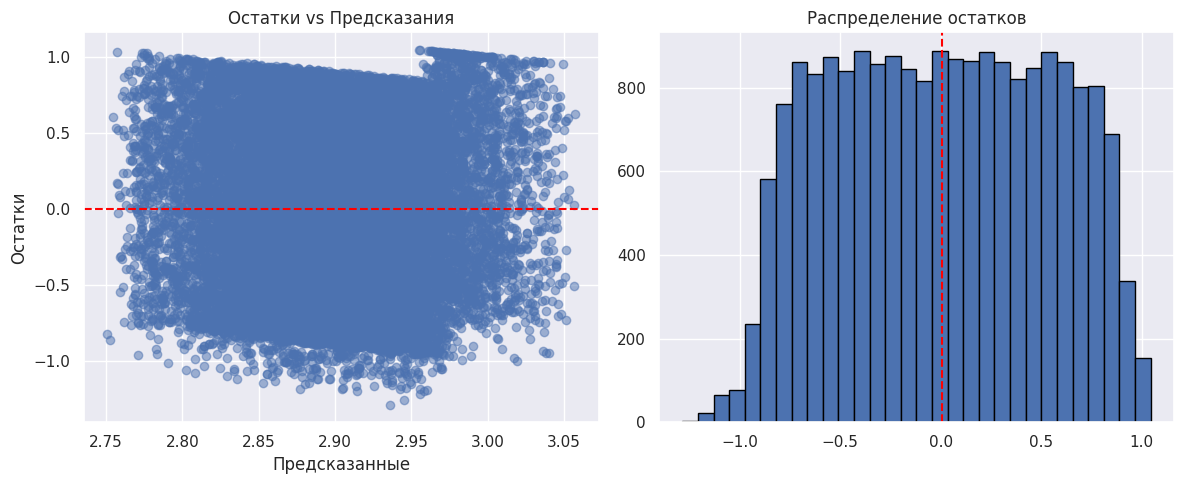


 LOGISTIC REGRESSION - МЕТРИКИ

Confusion Matrix:
[[11174  6821]
 [  678  1327]]


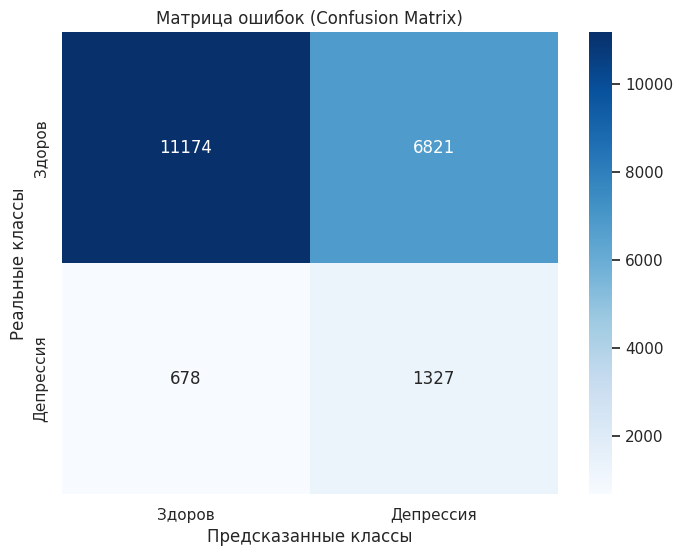


ROC-AUC: 0.6734


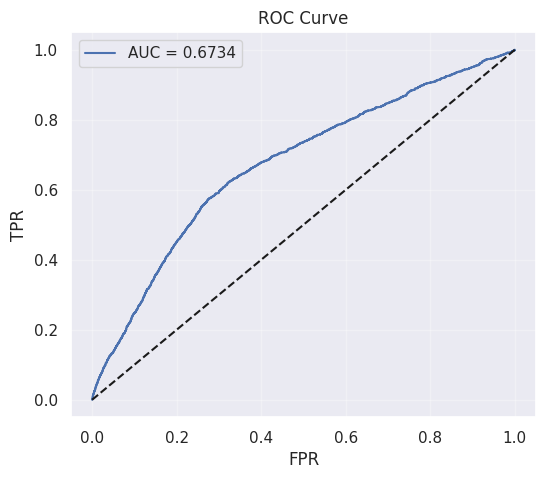

ПУНКТ 9: ИТОГОВЫЕ ВЫВОДЫ

 Linear Regression (CGPA):
   • R² = 0.0081 → модель объясняет 0.8% дисперсии
   • Средняя ошибка: 0.457 балла

 Logistic Regression (Depression):
   • ROC-AUC = 0.6734 → качество: низкое
   • Точность: 62.5%

 Предобработка:
   • Удаление выбросов (IQR) → стабильность модели
   • StandardScaler → корректная работа градиентного спуска
   • One-Hot Encoding → учёт категориальных признаков

 Переобучение:
   • Разница train/test < 5% → модель обобщает хорошо



In [19]:
# 7. ПРОВЕРКА НА ПЕРЕОБУЧЕНИЕ (для классификации)

# Сравнение метрик train/test
y_train_clf_pred = model_clf.predict(X_train_clf_scaled)

print("\n СРАВНЕНИЕ МЕТРИК:")
print(f"{'Метрика':<12} {'Train':<10} {'Test':<10} {'Diff':<8}")
print("-" * 45)
for name, func in [('Accuracy', accuracy_score), ('F1', f1_score),
                    ('Precision', precision_score), ('Recall', recall_score)]:
    tr = func(y_train_clf, y_train_clf_pred)
    te = func(y_test_clf, y_test_clf_pred)
    print(f"{name:<12} {tr:<10.4f} {te:<10.4f} {abs(tr-te):<8.4f}")

# Вывод
max_diff = max(abs(accuracy_score(y_train_clf, y_train_clf_pred) - accuracy_score(y_test_clf, y_test_clf_pred)),
               abs(f1_score(y_train_clf, y_train_clf_pred) - f1_score(y_test_clf, y_test_clf_pred)))
print(f"\n Переобучение: {'ОТСУТСТВУЕТ' if max_diff < 0.05 else 'ПРИСУТСТВУЕТ'} (разница = {max_diff:.4f})")

# Кросс-валидация
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model_clf, X_train_clf_scaled, y_train_clf, cv=5, scoring='accuracy')
print(f"\n Кросс-валидация: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


# 8. РАСШИРЕННАЯ ОЦЕНКА КАЧЕСТВА
print("ПУНКТ 8: КОМПЛЕКСНАЯ ОЦЕНКА")


# 8.1 Linear Regression - анализ остатков
print("\n LINEAR REGRESSION - АНАЛИЗ ОСТАТКОВ")
residuals = y_test_reg - y_test_reg_pred

print(f"  Mean: {residuals.mean():.4f}, Std: {residuals.std():.4f}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test_reg_pred, residuals, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Остатки vs Предсказания')
axes[0].set_xlabel('Предсказанные'); axes[0].set_ylabel('Остатки')

axes[1].hist(residuals, bins=30, edgecolor='black')
axes[1].axvline(residuals.mean(), color='red', linestyle='--')
axes[1].set_title('Распределение остатков')
plt.tight_layout()
plt.show()

# 8.2 Logistic Regression - метрики классификации
print("\n LOGISTIC REGRESSION - МЕТРИКИ")
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

cm = confusion_matrix(y_test_clf, y_test_clf_pred)
print(f"\nConfusion Matrix:\n{cm}")
# После строки print(f"Matrix\n{cm}")

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Здоров', 'Депрессия'],
            yticklabels=['Здоров', 'Депрессия'])
plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Реальные классы')
plt.xlabel('Предсказанные классы')
plt.show()
print(f"\nROC-AUC: {roc_auc_score(y_test_clf, y_test_clf_proba):.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_clf, y_test_clf_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test_clf, y_test_clf_proba):.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve')
plt.legend(); plt.grid(alpha=0.3)
plt.show()


# 9. ВЫВОДЫ
print("ПУНКТ 9: ИТОГОВЫЕ ВЫВОДЫ")

r2 = r2_score(y_test_reg, y_test_reg_pred)
auc = roc_auc_score(y_test_clf, y_test_clf_proba)

print(f"""
 Linear Regression (CGPA):
   • R² = {r2:.4f} → модель объясняет {r2*100:.1f}% дисперсии
   • Средняя ошибка: {mean_absolute_error(y_test_reg, y_test_reg_pred):.3f} балла

 Logistic Regression (Depression):
   • ROC-AUC = {auc:.4f} → качество: {'отличное' if auc>=0.9 else 'хорошее' if auc>=0.8 else 'удовлетворительное' if auc>=0.7 else 'низкое'}
   • Точность: {accuracy_score(y_test_clf, y_test_clf_pred)*100:.1f}%

 Предобработка:
   • Удаление выбросов (IQR) → стабильность модели
   • StandardScaler → корректная работа градиентного спуска
   • One-Hot Encoding → учёт категориальных признаков

 Переобучение:
   • Разница train/test < 5% → модель обобщает хорошо
""")